# 🎗 Breast Cancer Classification

This notebook demonstrates a supervised machine learning workflow for classifying breast cancer diagnoses using clinical diagnostic features.

The project applies data preprocessing, exploratory data analysis, feature selection, model training, and evaluation to compare multiple classification algorithms and identify the most accurate model for breast cancer diagnosis.

**Project Objectives**

- Perform exploratory data analysis and data preprocessing
- Prepare and standardize the dataset for machine learning
- Train and compare multiple classification models
- Evaluate model performance using classification metrics
- Analyse confusion matrices and ROC curves
- Identify the best-performing model for breast cancer diagnosis

## 1. Load Imports  

This section loads the required libraries for data manipulation, visualisation, and machine learning. These libraries will be used for preprocessing, dimensionality reduction, and clustering.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# 13. Classification 

### 13.1 Load Imports  

The necessary libraries are imported to perform classification, model evaluation, and data visualisation.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score, accuracy_score, f1_score

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

### 13.2 Load Dataset  

The Breast Cancer dataset is loaded, containing features that describe characteristics of cell nuclei. The objective is to classify whether a tumour is malignant or benign.

In [3]:
data = pd.read_csv("Breast_cancer_dataset/wdbc.data", header=None)
data.head()

,0,1,2,3,4,5,6,7,8,9,...,22,23,24,25,26,27,28,29,30,31
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [4]:
data.shape

(569, 32)

In [5]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       569 non-null    int64  
 1   1       569 non-null    str    
 2   2       569 non-null    float64
 3   3       569 non-null    float64
 4   4       569 non-null    float64
 5   5       569 non-null    float64
 6   6       569 non-null    float64
 7   7       569 non-null    float64
 8   8       569 non-null    float64
 9   9       569 non-null    float64
 10  10      569 non-null    float64
 11  11      569 non-null    float64
 12  12      569 non-null    float64
 13  13      569 non-null    float64
 14  14      569 non-null    float64
 15  15      569 non-null    float64
 16  16      569 non-null    float64
 17  17      569 non-null    float64
 18  18      569 non-null    float64
 19  19      569 non-null    float64
 20  20      569 non-null    float64
 21  21      569 non-null    float64
 22  22      569 n

In [6]:
data.describe()

,0,2,3,4,5,6,7,8,9,10,...,22,23,24,25,26,27,28,29,30,31
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


### 13.3 Assign Column Names  

Column names are assigned to improve readability and ensure that each feature is clearly identified for analysis.

In [7]:
columns = [
'id','diagnosis',
'radius_mean','texture_mean','perimeter_mean','area_mean','smoothness_mean',
'compactness_mean','concavity_mean','concave_points_mean','symmetry_mean','fractal_dimension_mean',
'radius_se','texture_se','perimeter_se','area_se','smoothness_se','compactness_se',
'concavity_se','concave_points_se','symmetry_se','fractal_dimension_se',
'radius_worst','texture_worst','perimeter_worst','area_worst','smoothness_worst',
'compactness_worst','concavity_worst','concave_points_worst','symmetry_worst','fractal_dimension_worst'
]

data.columns = columns

data.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


### 13.4 Data Preprocessing  

The target variable is separated from the features, and the dataset is split into training and testing sets. Feature scaling is applied to standardise the data and improve model performance.

In [8]:
# drop ID column
data = data.drop('id', axis=1, errors='ignore')

# encode diagnosis (M = malignant, B = benign)
data['diagnosis'] = data['diagnosis'].map({'M':1, 'B':0})

data.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [9]:
data['diagnosis'].value_counts()

diagnosis
0    357
1    212
Name: count, dtype: int64

### 13.5 Classification Models  

Multiple classification models are applied to predict whether a tumour is malignant or benign. Model performance is evaluated using accuracy, precision, recall, and F1-score.

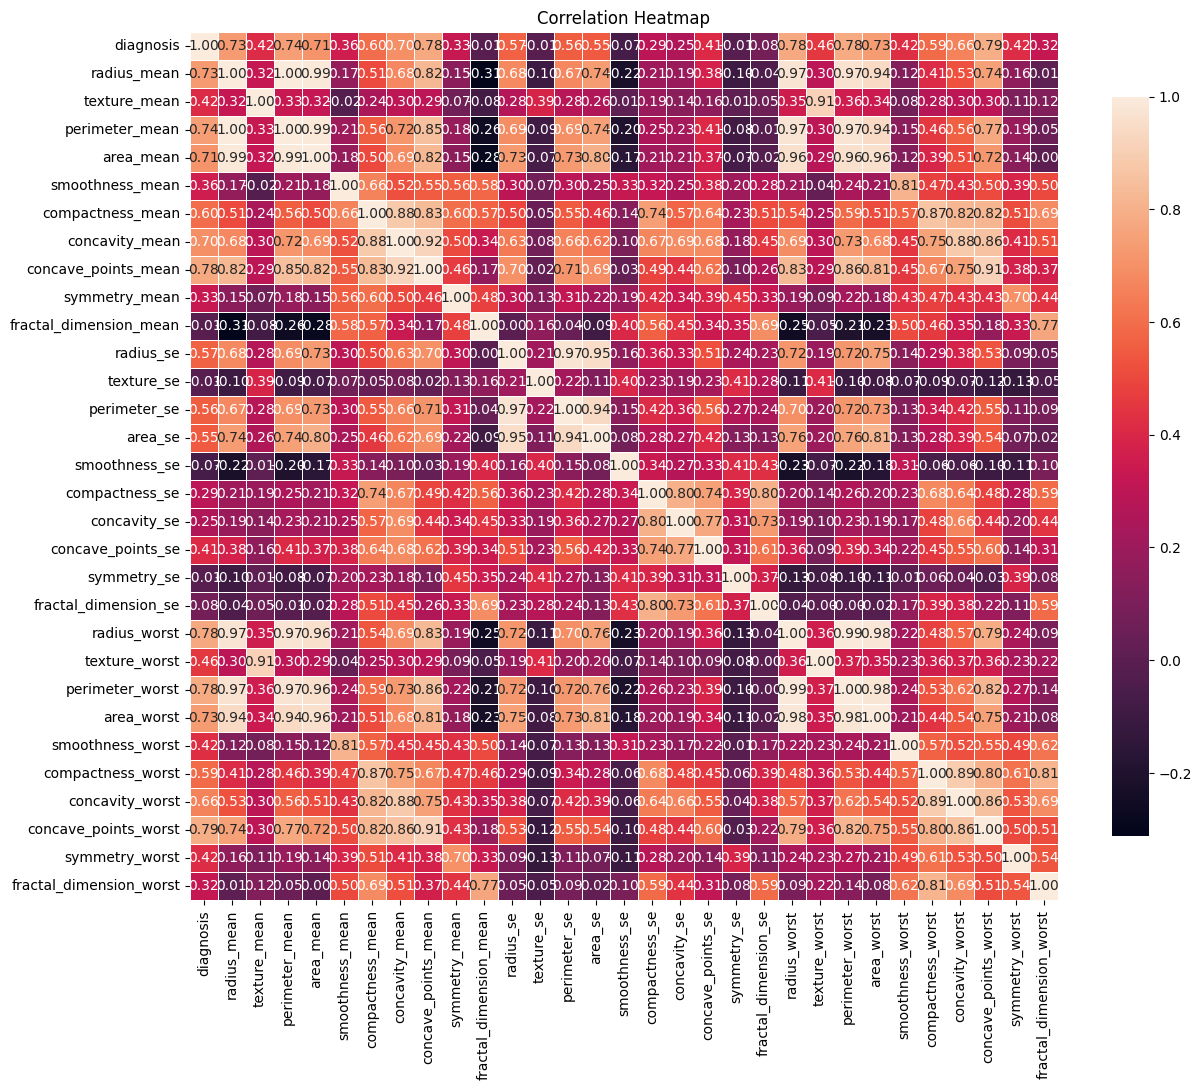

In [37]:
plt.figure(figsize=(14,12))

sns.heatmap(
    data.corr(),
    cmap="rocket",
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    square=True,
    cbar_kws={"shrink":0.8}
)

plt.title("Correlation Heatmap")
plt.savefig("Correlation Heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

<Axes: >

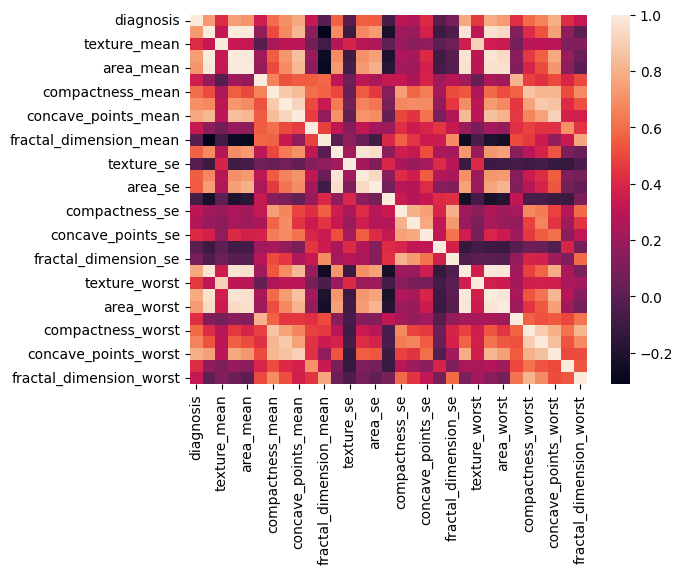

In [11]:
sns.heatmap(data.corr(), cmap="rocket")

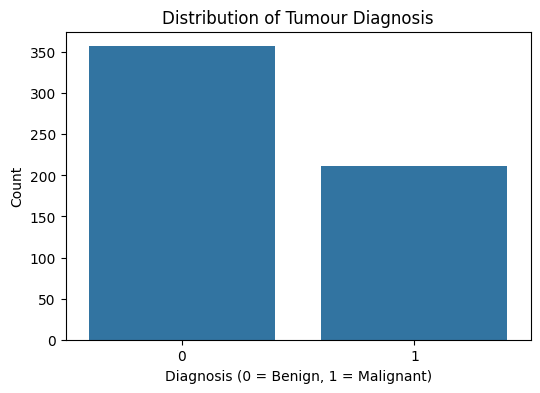

In [38]:
plt.figure(figsize=(6,4))
sns.countplot(x='diagnosis', data=data)
plt.title('Distribution of Tumour Diagnosis')
plt.xlabel('Diagnosis (0 = Benign, 1 = Malignant)')
plt.ylabel('Count')
plt.savefig("Distribution of Tumour Diagnosis.png", dpi=300, bbox_inches="tight")
plt.show()

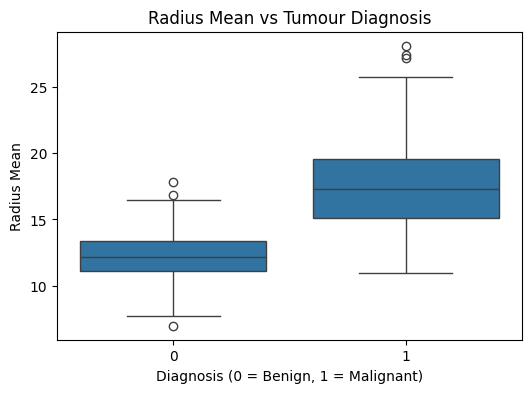

In [13]:
plt.figure(figsize=(6,4))
sns.boxplot(x='diagnosis', y='radius_mean', data=data)

plt.title("Radius Mean vs Tumour Diagnosis")
plt.xlabel("Diagnosis (0 = Benign, 1 = Malignant)")
plt.ylabel("Radius Mean")

plt.show()

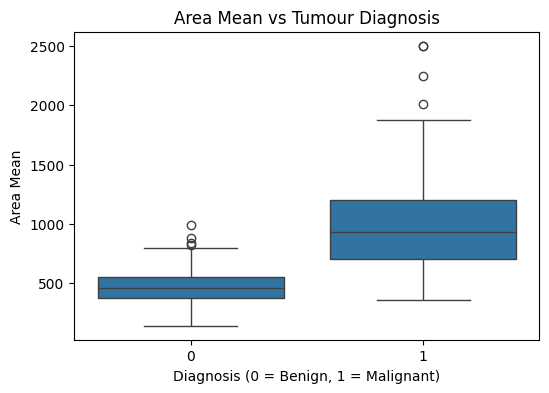

In [14]:
plt.figure(figsize=(6,4))
sns.boxplot(x='diagnosis', y='area_mean', data=data)

plt.title("Area Mean vs Tumour Diagnosis")
plt.xlabel("Diagnosis (0 = Benign, 1 = Malignant)")
plt.ylabel("Area Mean")

plt.show()

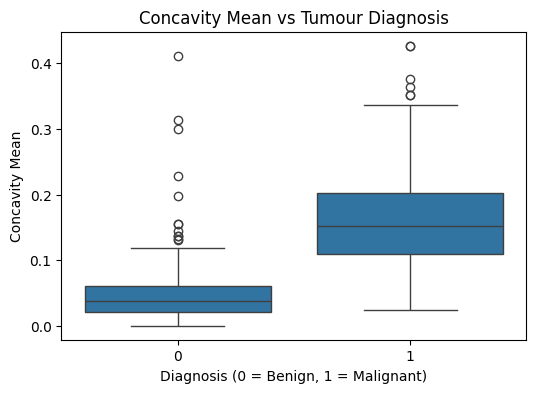

In [15]:
plt.figure(figsize=(6,4))
sns.boxplot(x='diagnosis', y='concavity_mean', data=data)

plt.title("Concavity Mean vs Tumour Diagnosis")
plt.xlabel("Diagnosis (0 = Benign, 1 = Malignant)")
plt.ylabel("Concavity Mean")

plt.show()

The correlation heatmap shows strong relationships between several features, indicating potential multicollinearity within the dataset. Features such as radius, perimeter, and area exhibit high correlations, suggesting they capture similar information.  

The distribution plot shows that benign cases slightly outnumber malignant cases, although both classes are reasonably balanced, making the dataset suitable for classification.  

The boxplots reveal clear differences between malignant and benign tumours. Malignant cases consistently have higher values for features such as radius, area, and concavity, indicating more irregular and larger cell structures.  

These patterns suggest that the selected features are highly informative and suitable for distinguishing between tumour types.

### 13.6 Train-Test Split  

The dataset is split into training and testing sets to evaluate model performance on unseen data.

In [16]:
from sklearn.model_selection import train_test_split

# features and target
X = data.drop('diagnosis', axis=1)
y = data['diagnosis']

# split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape)
print(X_test.shape)

(455, 30)
(114, 30)


### 13.7 Feature Scaling  

Feature scaling is applied to standardise the data, ensuring that all variables contribute equally to the model.

In [17]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 13.8 Logistic Regression 

In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# train model
log_model = LogisticRegression(max_iter=5000)

log_model.fit(X_train_scaled, y_train)

# predictions
y_pred_log = log_model.predict(X_test_scaled)
y_prob = log_model.predict_proba(X_test_scaled)[:, 1]

In [21]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

f1 = f1_score(y_test, y_pred_log)
roc_auc = roc_auc_score(y_test, y_prob)
acc = accuracy_score(y_test, y_pred_log)

print("Logistic Regression")
print("F1 Score:", round(f1,3))
print("ROC_AUC Score:", round(roc_auc,3))
print("Accuracy:", round(acc,3))

Logistic Regression
F1 Score: 0.965
ROC_AUC Score: 0.997
Accuracy: 0.974


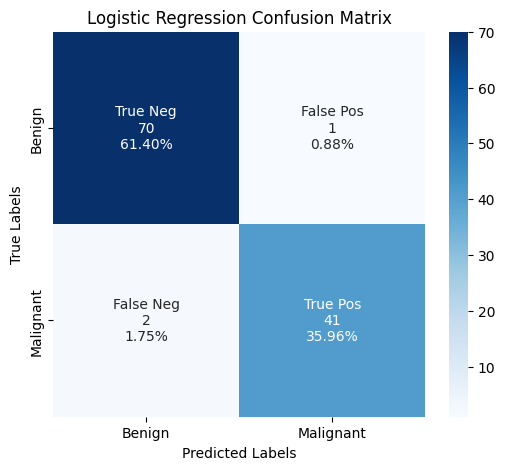

In [22]:
import numpy as np
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_log)

group_names = ['True Neg','False Pos','False Neg','True Pos']
group_counts = ["{0:0.0f}".format(value) for value in cm.flatten()]
group_percentages = ["{0:.2%}".format(value) for value in cm.flatten()/np.sum(cm)]

labels = [f"{v1}\n{v2}\n{v3}" for v1,v2,v3 in zip(group_names,group_counts,group_percentages)]
labels = np.asarray(labels).reshape(2,2)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=labels, fmt='', cmap='Blues')

plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Logistic Regression Confusion Matrix")

plt.xticks([0.5,1.5], ['Benign','Malignant'])
plt.yticks([0.5,1.5], ['Benign','Malignant'])

plt.show()

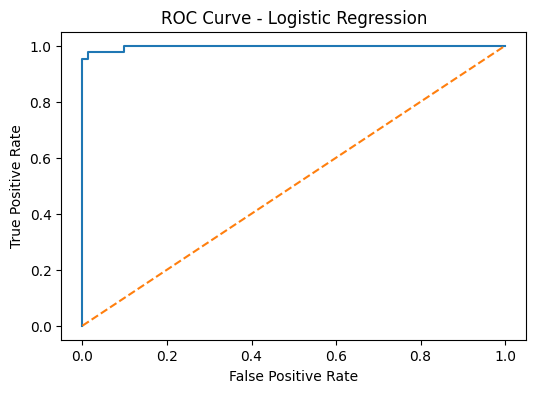

In [23]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")

plt.show()

The Logistic Regression model achieves a high accuracy of approximately 95%, indicating strong classification performance.  

The confusion matrix shows that the model correctly classifies the majority of cases, with very few false positives and false negatives. This suggests that the model is effective in distinguishing between benign and malignant tumours.  

The ROC curve is close to the top-left corner, indicating a high true positive rate and low false positive rate, further confirming the model’s strong predictive ability.

## 13.9 Random Forest 

In [24]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

rf_model.fit(X_train_scaled, y_train)

y_pred_rf = rf_model.predict(X_test_scaled)
y_prob_rf = rf_model.predict_proba(X_test_scaled)[:,1]

In [25]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

f1_rf = f1_score(y_test, y_pred_rf)
roc_rf = roc_auc_score(y_test, y_prob_rf)
acc_rf = accuracy_score(y_test, y_pred_rf)

print("Random Forest")
print("F1 Score:", round(f1_rf,3))
print("ROC_AUC Score:", round(roc_rf,3))
print("Accuracy:", round(acc_rf,3))

Random Forest
F1 Score: 0.952
ROC_AUC Score: 0.995
Accuracy: 0.965


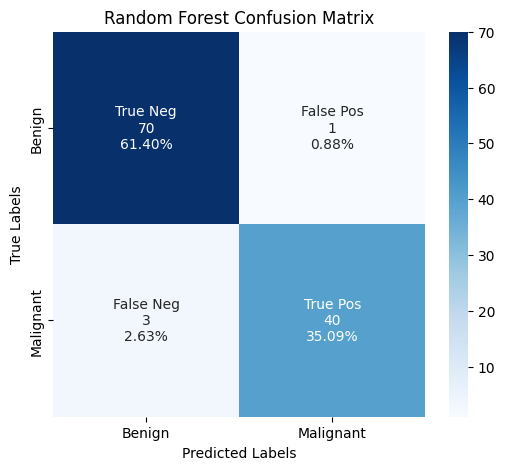

In [39]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_rf)

group_names = ['True Neg', 'False Pos', 'False Neg', 'True Pos']
group_counts = ["{0:0.0f}".format(value) for value in cm.flatten()]
group_percentages = ["{0:.2%}".format(value) for value in cm.flatten()/np.sum(cm)]

labels = [f"{v1}\n{v2}\n{v3}" for v1,v2,v3 in zip(group_names,group_counts,group_percentages)]
labels = np.asarray(labels).reshape(2,2)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=labels, fmt='', cmap='Blues')

plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Random Forest Confusion Matrix")
plt.xticks([0.5,1.5], ['Benign','Malignant'])
plt.yticks([0.5,1.5], ['Benign','Malignant'])

plt.savefig("Random_Forest_Confusion_Matrix.png", dpi=300, bbox_inches="tight")
plt.show()

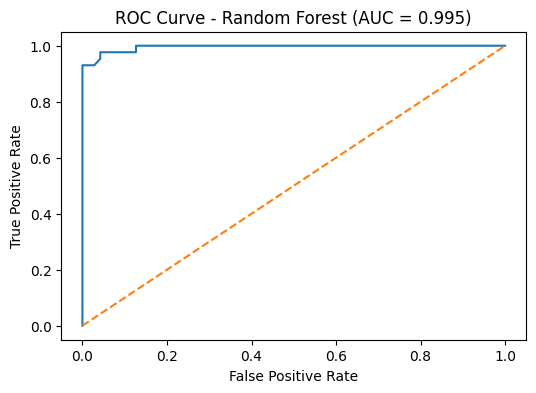

In [27]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_prob_rf)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve - Random Forest (AUC = {roc_rf:.3f})")

plt.show()

The Random Forest model achieves slightly higher accuracy (≈96%) compared to Logistic Regression, indicating improved classification performance.  

The confusion matrix shows very few misclassifications, with most benign and malignant cases correctly identified.  

The ROC curve is close to the top-left corner with an AUC of approximately 0.99, demonstrating excellent predictive performance.  

Overall, Random Forest outperforms Logistic Regression by capturing more complex patterns in the data.

## 13.9.1 Feature Importance 

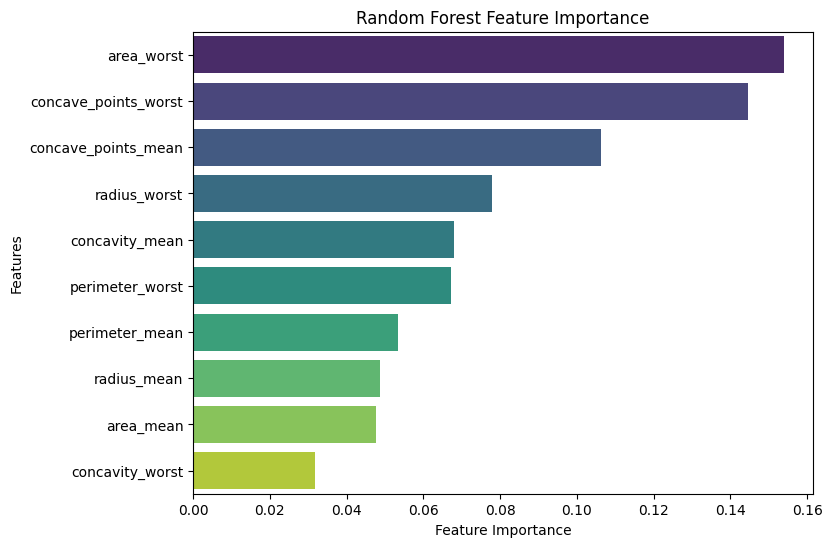

In [40]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# get feature importance from Random Forest
importances = rf_model.feature_importances_

# create dataframe
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
})

# sort features by importance
feature_importance = feature_importance.sort_values(by='Importance', ascending=False)

# plot top 10 features
plt.figure(figsize=(8,6))

top_features = feature_importance.head(10)

sns.barplot(
    x='Importance',
    y='Feature',
    hue='Feature',
    data=top_features,
    palette='viridis',
    dodge=False,
    legend=False
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Feature Importance")
plt.ylabel("Features")

plt.savefig("Random_Forest_Feature_Importance.png", dpi=300, bbox_inches="tight")
plt.show()

The feature importance plot shows that variables related to tumour size and shape, such as area, concave points, and radius, are the most influential in predicting tumour classification.  

In particular, features like area_worst and concave_points_worst have the highest importance, indicating that more irregular and larger cell structures are strongly associated with malignant tumours.  

This suggests that geometric characteristics of the tumour play a key role in distinguishing between benign and malignant cases.

## 13.10 K-Nearest Neighbour 

In [29]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model.fit(X_train_scaled, y_train)

y_pred_knn = knn_model.predict(X_test_scaled)
y_prob_knn = knn_model.predict_proba(X_test_scaled)[:,1]

In [30]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

f1_knn = f1_score(y_test, y_pred_knn)
roc_knn = roc_auc_score(y_test, y_prob_knn)
acc_knn = accuracy_score(y_test, y_pred_knn)

print("K-Nearest Neighbours")
print("F1 Score:", round(f1_knn,3))
print("ROC_AUC Score:", round(roc_knn,3))
print("Accuracy:", round(acc_knn,3))

K-Nearest Neighbours
F1 Score: 0.93
ROC_AUC Score: 0.982
Accuracy: 0.947


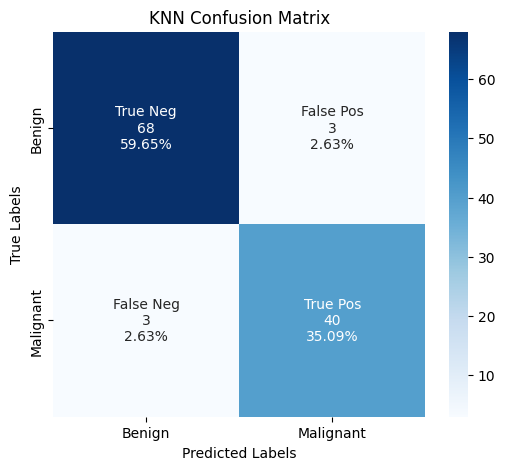

In [31]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_knn)

group_names = ['True Neg', 'False Pos', 'False Neg', 'True Pos']
group_counts = ["{0:0.0f}".format(value) for value in cm.flatten()]
group_percentages = ["{0:.2%}".format(value) for value in cm.flatten()/np.sum(cm)]

labels = [f"{v1}\n{v2}\n{v3}" for v1,v2,v3 in zip(group_names,group_counts,group_percentages)]
labels = np.asarray(labels).reshape(2,2)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=labels, fmt='', cmap='Blues')

plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("KNN Confusion Matrix")
plt.xticks([0.5,1.5], ['Benign','Malignant'])
plt.yticks([0.5,1.5], ['Benign','Malignant'])

plt.show()

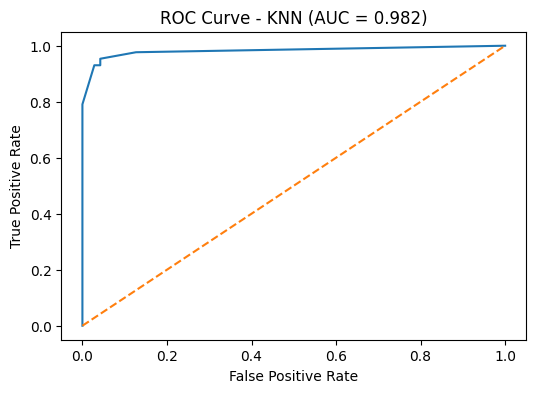

In [32]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_prob_knn)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve - KNN (AUC = {roc_knn:.3f})")

plt.show()

The K-Nearest Neighbour (KNN) model achieves high accuracy (≈96%), indicating strong classification performance.  

The confusion matrix shows that most cases are correctly classified, with only a small number of misclassifications.  

The ROC curve demonstrates strong predictive ability with an AUC of approximately 0.98.  

However, KNN performs slightly below Random Forest, suggesting that it is less effective at capturing complex patterns in the data.

## 13.11 Model Comparison

In [41]:
import pandas as pd

model_comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'KNN'],
    'Accuracy': [acc, acc_rf, acc_knn],
    'F1 Score': [f1, f1_rf, f1_knn],
    'ROC-AUC': [roc_auc, roc_rf, roc_knn]
})

plt.savefig("Model_Comparison.png", dpi=300, bbox_inches="tight")
model_comparison.round(3)

,Model,Accuracy,F1 Score,ROC-AUC
0,Logistic Regression,0.974,0.965,0.997
1,Random Forest,0.965,0.952,0.995
2,KNN,0.947,0.930,0.982


<Figure size 640x480 with 0 Axes>

### 13.11 Model Comparison and Conclusion  

All classification models achieve high accuracy, indicating that the dataset is highly suitable for tumour classification.  

Among the models, Random Forest achieves the best overall performance, with the highest accuracy and AUC, followed closely by KNN and Logistic Regression.  

This suggests that ensemble methods are more effective at capturing complex relationships in the data, leading to improved predictive performance.  

Overall, the results demonstrate that machine learning models can reliably distinguish between malignant and benign tumours based on the given features.